# Plant Disease Classification using EfficientNetB0

## Project Objective

The goal of this project is to develop an end-to-end deep learning model capable of automatically identifying plant diseases from leaf images.

This project demonstrates:

- Data Understanding
- Exploratory Data Analysis
- Image Preprocessing
- Data Augmentation
- Transfer Learning
- Model Training
- Model Evaluation
- Explainable AI using Grad-CAM
- Streamlit Deployment

The trained model will classify plant diseases from uploaded leaf images and provide prediction confidence along with visual explanations.

# Problem Statement

Plant diseases significantly reduce agricultural productivity.

Traditional disease identification requires agricultural experts and is time-consuming.

The objective of this project is to build an automated plant disease classification system using Deep Learning that can accurately identify diseases from leaf images.

# Dataset Overview

Dataset Name

Master Plant Disease Dataset

Dataset Size

≈ 66,700 Images

Number of Classes

281 Disease Classes

Dataset Structure

Dataset/

       │

       ├── master_images/

       ├── outputs/

       ├── metadata/

The dataset already contains predefined Training, Validation and Testing splits.

# 1.Import Libraries

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
#import cv2

import tensorflow as tf
#from tensorflow.keras import layers
#from tensorflow.keras import models

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# 2.Read CSV Files

In [2]:
#Define Dataset Paths

DATASET_PATH = "Dataset"
IMAGE_DIR = os.path.join(DATASET_PATH, "master_images")
OUTPUT_DIR = os.path.join(DATASET_PATH, "outputs")
META_DIR = os.path.join(DATASET_PATH, "metadata")

In [3]:
train_df = pd.read_csv(os.path.join(OUTPUT_DIR, "train_split.csv"))

val_df = pd.read_csv(os.path.join(OUTPUT_DIR, "val_split.csv"))

test_df = pd.read_csv(os.path.join(OUTPUT_DIR, "test_split.csv"))

class_id_df = pd.read_csv(os.path.join(META_DIR, "class_id_map.csv"))

class_map_df = pd.read_csv(os.path.join(META_DIR, "class_map.csv"))

# 3.Explore & Inspect Dataset

In [4]:
#dimensions

print("Training Shape :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Testing Shape :", test_df.shape)

Training Shape : (53360, 10)
Validation Shape : (6670, 10)
Testing Shape : (6671, 10)


In [5]:
#contents of tables

print("="*60)
print("Training Dataset")
print("="*60)
print(train_df.head())

print("\n")

print("="*60)
print("Validation Dataset")
print("="*60)
print(val_df.head())

print("\n")

print("="*60)
print("Testing Dataset")
print("="*60)
print(test_df.head())

Training Dataset
       image_id               image_path               canonical_class  \
0  img_00025856  images/img_00025856.JPG         Tomato - Spider Mites   
1  img_00038397  images/img_00038397.jpg  Garlic - garlic leaf blight    
2  img_00016302  images/img_00016302.JPG  Bell Pepper - Bacterial Spot   
3  img_00052992  images/img_00052992.jpg             Banana - Sigatoka   
4  img_00053059  images/img_00053059.jpg              Banana - Healthy   

   class_id         crop                    source_dataset  width  height  \
0       228       Tomato  PlantVillageDataset/PlantVillage    256     256   
1       121       Garlic                          plantseg    640     464   
2        40  Bell Pepper  PlantVillageDataset/PlantVillage    256     256   
3        18       Banana                   Multicrop/train    640     640   
4        13       Banana                   Multicrop/train    640     640   

                                   original_filename  mask_path  
0  423380

In [6]:
#summary

print("="*60)
print("Training Dataset")
print("="*60)
train_df.info()

print("\n")

print("="*60)
print("Validation Dataset")
print("="*60)
val_df.info()

print("\n")

print("="*60)
print("Testing Dataset")
print("="*60)
test_df.info()

Training Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53360 entries, 0 to 53359
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   image_id           53360 non-null  object 
 1   image_path         53360 non-null  object 
 2   canonical_class    53360 non-null  object 
 3   class_id           53360 non-null  int64  
 4   crop               53360 non-null  object 
 5   source_dataset     53360 non-null  object 
 6   width              53360 non-null  int64  
 7   height             53360 non-null  int64  
 8   original_filename  53360 non-null  object 
 9   mask_path          0 non-null      float64
dtypes: float64(1), int64(3), object(6)
memory usage: 4.1+ MB


Validation Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6670 entries, 0 to 6669
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   image_i

In [7]:
#statistics

print("="*50)
print("Dataset Statistics")
print("="*50)

print(f"Training Images   : {len(train_df):,}")
print(f"Validation Images : {len(val_df):,}")
print(f"Testing Images    : {len(test_df):,}")

print(f"Total Classes     : {train_df['canonical_class'].nunique()}")
print(f"Plant Species     : {train_df['crop'].nunique()}")

print("="*50)

Dataset Statistics
Training Images   : 53,360
Validation Images : 6,670
Testing Images    : 6,671
Total Classes     : 281
Plant Species     : 42


# 4.Missing Values

In [8]:
# Remove the unnecessary "images/" prefix from all image paths
train_df["image_path"] = train_df["image_path"].str.replace("images/", "", regex=False)
val_df["image_path"] = val_df["image_path"].str.replace("images/", "", regex=False)
test_df["image_path"] = test_df["image_path"].str.replace("images/", "", regex=False)

In [9]:
def check_missing_images(df, split_name):
    
    missing = []
    
    for img_path in df["image_path"]:
        full_path = os.path.join(IMAGE_DIR, img_path)
        
        if not os.path.exists(full_path):
            missing.append(img_path)
    
    print(f"{split_name} missing images: {len(missing)}")
    
    return missing


missing_train = check_missing_images(train_df, "Training")
missing_val = check_missing_images(val_df, "Validation")
missing_test = check_missing_images(test_df, "Testing")

Training missing images: 0
Validation missing images: 0
Testing missing images: 0


In [10]:
# Drop the mask_path column since it is not required for image classification
train_df = train_df.drop(columns=["mask_path"])
val_df = val_df.drop(columns=["mask_path"])
test_df = test_df.drop(columns=["mask_path"])

In [11]:
print("Training Missing Values")
print(train_df.isnull().sum())

print("\nValidation Missing Values")
print(val_df.isnull().sum())

print("\nTesting Missing Values")
print(test_df.isnull().sum())

Training Missing Values
image_id             0
image_path           0
canonical_class      0
class_id             0
crop                 0
source_dataset       0
width                0
height               0
original_filename    0
dtype: int64

Validation Missing Values
image_id             0
image_path           0
canonical_class      0
class_id             0
crop                 0
source_dataset       0
width                0
height               0
original_filename    0
dtype: int64

Testing Missing Values
image_id             0
image_path           0
canonical_class      0
class_id             0
crop                 0
source_dataset       0
width                0
height               0
original_filename    0
dtype: int64


# 5.Duplicate Records

In [12]:
#verified that the predefined train, validation and test splits contain no overlapping image IDs
print("Train IDs:", train_df["image_id"].nunique())
print("Validation IDs:", val_df["image_id"].nunique())
print("Test IDs:", test_df["image_id"].nunique())

train_val_overlap = set(train_df["image_id"]) & set(val_df["image_id"])
train_test_overlap = set(train_df["image_id"]) & set(test_df["image_id"])
val_test_overlap = set(val_df["image_id"]) & set(test_df["image_id"])

print("\nCross-Split Overlap")
print("Train ↔ Validation:", len(train_val_overlap))
print("Train ↔ Test:", len(train_test_overlap))
print("Validation ↔ Test:", len(val_test_overlap))

Train IDs: 53360
Validation IDs: 6670
Test IDs: 6671

Cross-Split Overlap
Train ↔ Validation: 0
Train ↔ Test: 0
Validation ↔ Test: 0


In [13]:
train_df.duplicated().sum()

np.int64(0)

# 6.Exploratory Data Analysis (EDA)

## 6.1 Number of Plant Species

Total Plant Species : 42
['Apple', 'Banana', 'Basil', 'Bean', 'Bell Pepper', 'Bell pepper', 'Blackgram', 'Blueberry', 'Broccoli', 'Cabbage', 'Carrot', 'Cauliflower', 'Celery', 'Cherry', 'Chilli', 'Citrus', 'Coffee', 'Corn', 'Cucumber', 'Eggplant', 'Garlic', 'Ginger', 'Grape', 'Grapevine', 'Groundnut', 'Lettuce', 'Maple', 'Paddy', 'Peach', 'Plum', 'Potato', 'Radish', 'Raspberry', 'Rice', 'Soybean', 'Squash', 'Strawberry', 'Sugarcane', 'Tobacco', 'Tomato', 'Wheat', 'Zucchini']


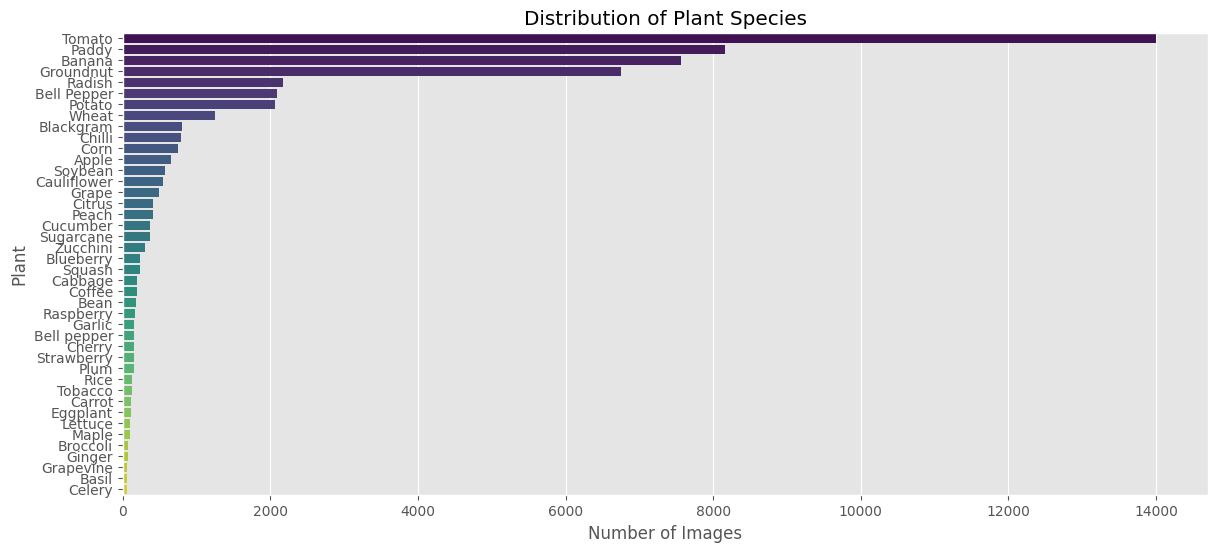

In [14]:
print("Total Plant Species :",train_df["crop"].nunique())

print(sorted(train_df["crop"].unique()))

plt.figure(figsize=(14,6))
sns.countplot(
    y=train_df["crop"],
    order=train_df["crop"].value_counts().index,
    palette="viridis"
)
plt.title("Distribution of Plant Species")
plt.xlabel("Number of Images")
plt.ylabel("Plant")
plt.show()

## 6.2 Number of Disease Classes

Total Disease Classes : 281


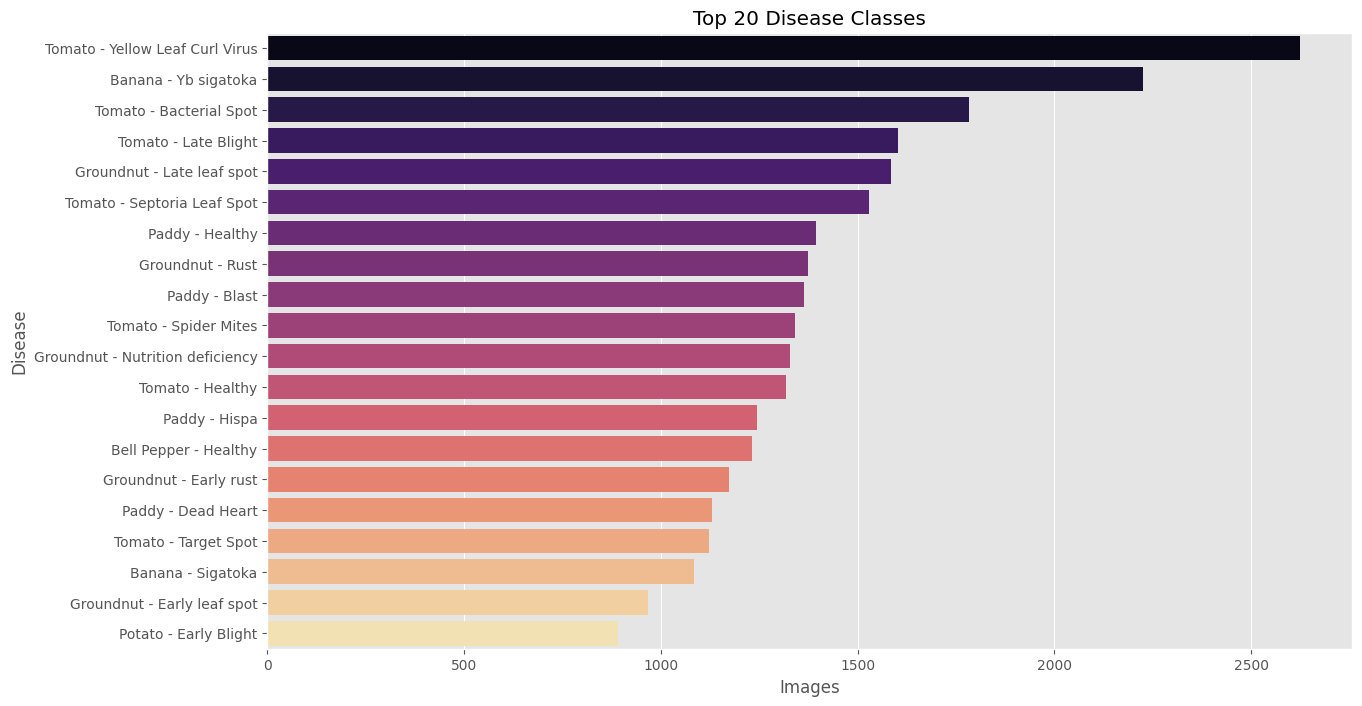

In [15]:
print("Total Disease Classes :",train_df["canonical_class"].nunique()) 

#Top 20 Disease Classes
plt.figure(figsize=(14,8))
top_classes = train_df["canonical_class"].value_counts().head(20)
sns.barplot(
    x=top_classes.values,
    y=top_classes.index,
    palette="magma"
)
plt.title("Top 20 Disease Classes")
plt.xlabel("Images")
plt.ylabel("Disease")
plt.show()

## 6.3 Source Dataset Distribution
Your dataset was merged from multiple public datasets.
This graph shows contribution from each dataset.

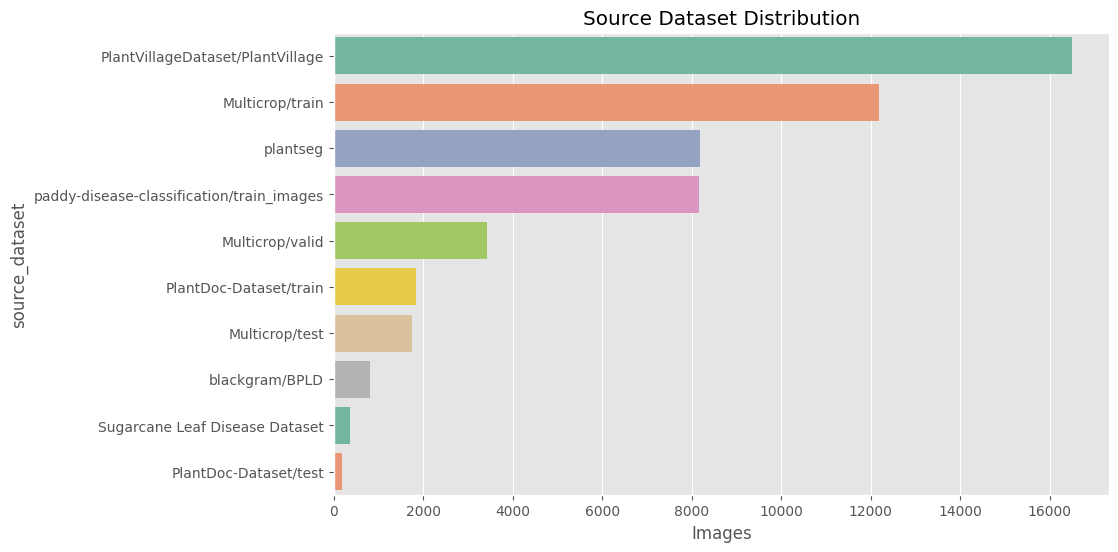

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(
    y=train_df["source_dataset"],
    order=train_df["source_dataset"].value_counts().index,
    palette="Set2"
)
plt.title("Source Dataset Distribution")
plt.xlabel("Images")
plt.show()

## 6.4 Image Width & Height Distribution

Image Dimension Statistics
----------------------------------------
Minimum Width  : 65 px
Maximum Width  : 6692 px
Average Width  : 540.61 px

Minimum Height : 52 px
Maximum Height : 6000 px
Average Height : 542.52 px


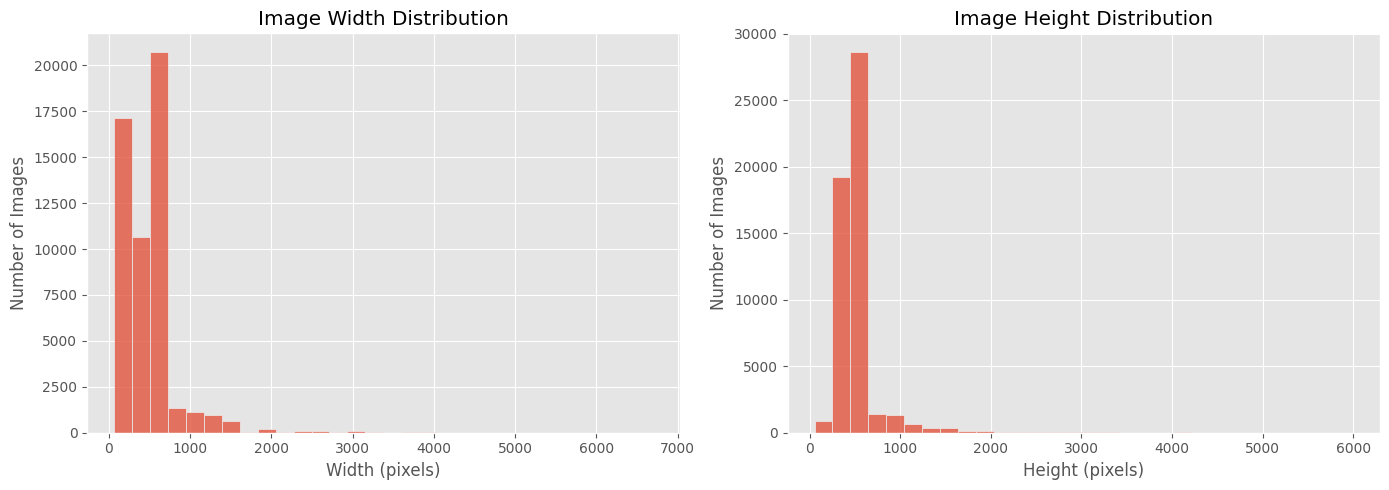

In [17]:
print("Image Dimension Statistics")
print("-" * 40)
print(f"Minimum Width  : {train_df['width'].min()} px")
print(f"Maximum Width  : {train_df['width'].max()} px")
print(f"Average Width  : {train_df['width'].mean():.2f} px")
print()
print(f"Minimum Height : {train_df['height'].min()} px")
print(f"Maximum Height : {train_df['height'].max()} px")
print(f"Average Height : {train_df['height'].mean():.2f} px")

plt.figure(figsize=(14,5))
# Width Distribution
plt.subplot(1,2,1)
sns.histplot(train_df["width"], bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")
# Height Distribution
plt.subplot(1,2,2)
sns.histplot(train_df["height"], bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## 6.5 Display Random Images

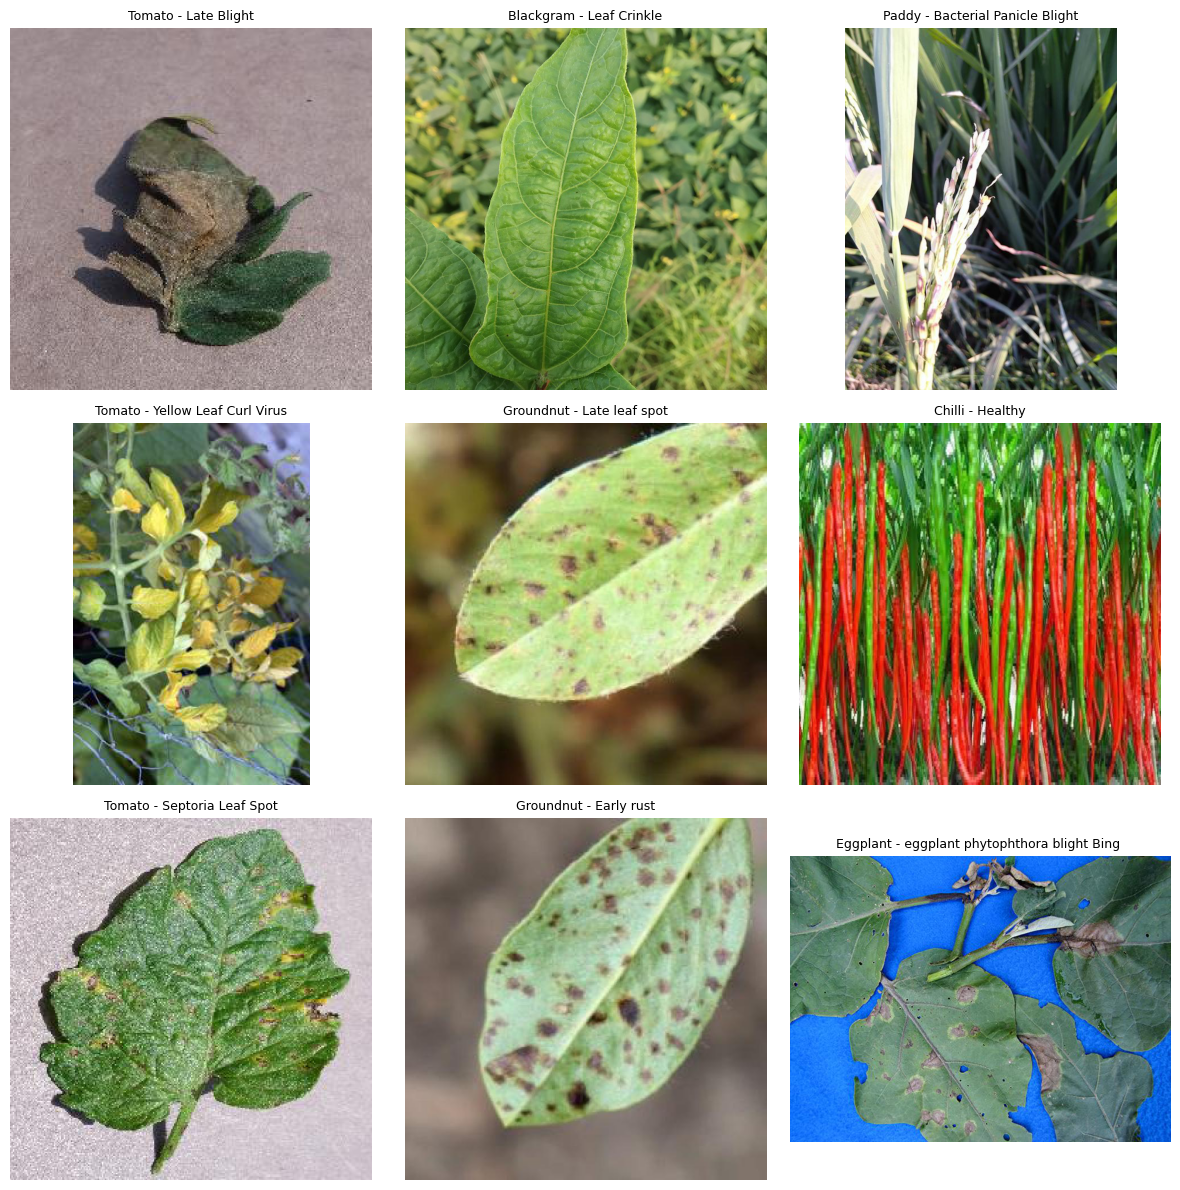

In [18]:
sample = train_df.sample(9, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(sample.iterrows()):

    image = Image.open(os.path.join(IMAGE_DIR, row["image_path"]))

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(row["canonical_class"], fontsize=9)

    plt.axis("off")

plt.tight_layout()

plt.show()

## 6.6 Number of Images per Split

      Dataset  Images
0       Train   53360
1  Validation    6670
2        Test    6671


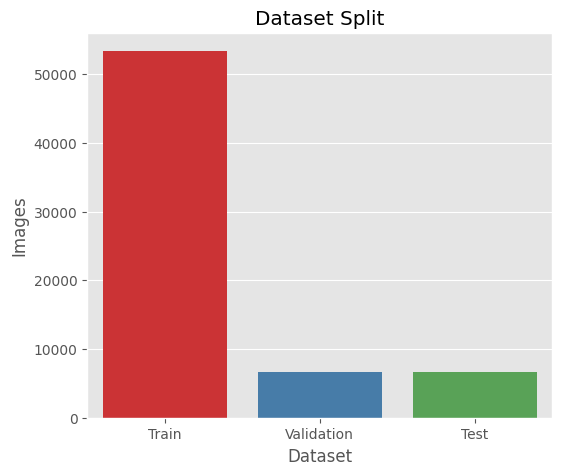

In [19]:
split_df = pd.DataFrame({
    "Dataset":["Train","Validation","Test"],
    "Images":[len(train_df),len(val_df),len(test_df)]
})
print(split_df)

plt.figure(figsize=(6,5))
sns.barplot(
    data=split_df,
    x="Dataset",
    y="Images",
    palette="Set1"
)
plt.title("Dataset Split")
plt.show()

## 6.7 Dataset Summary Table

In [20]:
summary = pd.DataFrame({
"Property":[
        "Training Images",
        "Validation Images",
        "Testing Images",
        "Disease Classes",
        "Plant Species",
        "Source Datasets",
        "Average Width",
        "Average Height"
    ],

    "Value":[
        len(train_df),
        len(val_df),
        len(test_df),
        train_df["canonical_class"].nunique(),
        train_df["crop"].nunique(),
        train_df["source_dataset"].nunique(),
        round(train_df["width"].mean(),2),
        round(train_df["height"].mean(),2)
    ]
})

summary

,Property,Value
0,Training Images,53360.00
1,Validation Images,6670.00
2,Testing Images,6671.00
3,Disease Classes,281.00
4,Plant Species,42.00
5,Source Datasets,10.00
6,Average Width,540.61
7,Average Height,542.52


In [21]:
##need to check

print("Duplicate canonical class names after whitespace normalization:")

normalized_classes = (
    train_df["canonical_class"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

class_check = pd.DataFrame({
    "original_class": train_df["canonical_class"],
    "normalized_class": normalized_classes,
    "class_id": train_df["class_id"]
})

duplicates = (
    class_check
    .groupby("normalized_class")["class_id"]
    .nunique()
)

print(duplicates[duplicates > 1])

Duplicate canonical class names after whitespace normalization:
normalized_class
Apple - apple black rot                     2
Apple - apple mosaic virus                  2
Apple - apple rust                          2
Apple - apple scab                          2
Banana - banana panama disease              2
Bean - bean mosaic virus                    2
Bean - bean rust                            2
Broccoli - broccoli downy mildew            2
Cabbage - cabbage alternaria leaf spot      2
Celery - celery early blight                2
Cherry - cherry leaf spot                   2
Citrus - citrus canker                      2
Citrus - citrus greening disease            2
Coffee - coffee leaf rust                   2
Corn - corn gray leaf spot                  2
Corn - corn northern leaf blight            2
Corn - corn rust                            2
Corn - corn smut                            2
Cucumber - cucumber angular leaf spot       2
Cucumber - cucumber bacterial wilt          2

## 7.Data Preprocessing

### 7.1 Prepare Image Paths

In [22]:
train_df["full_path"] = train_df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

val_df["full_path"] = val_df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

test_df["full_path"] = test_df["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

### 7.2 Extract Paths and Labels

In [23]:
train_paths = train_df["full_path"].values
train_labels = train_df["class_id"].values.astype("int32")

val_paths = val_df["full_path"].values
val_labels = val_df["class_id"].values.astype("int32")

test_paths = test_df["full_path"].values
test_labels = test_df["class_id"].values.astype("int32")

In [24]:
print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Testing:", len(test_paths))

Training: 53360
Validation: 6670
Testing: 6671


### 7.3 Create TensorFlow Datasets

In [25]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

### 7.4 Image Loading and Resizing

In [30]:
# Image and training configuration

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

print("Image Size :", IMG_SIZE)
print("Batch Size :", BATCH_SIZE)
print("AUTOTUNE   :", AUTOTUNE)

Image Size : (224, 224)
Batch Size : 16
AUTOTUNE   : -1


In [31]:
def load_image(path, label):
    
    image = tf.io.read_file(path)
    
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    
    image.set_shape([None, None, 3])
    
    image = tf.image.resize(
        image,
        IMG_SIZE
    )
    
    image = tf.cast(image, tf.float32)
    
    return image, label

In [32]:
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

### 7.5 Data Augmentation

Data augmentation generates slightly modified versions of training images.

This helps the model learn disease characteristics rather than memorizing the exact training images.

Augmentation is applied only to the training dataset.

In [33]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
], name="data_augmentation")


def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_ds = train_ds.map(
    augment_image,
    num_parallel_calls=AUTOTUNE
)

### 7.6 Batch the Dataset

In [34]:
train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

### 7.7 Optimize the Pipeline

In [35]:
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

### 7.8 Verify the Pipeline

In [36]:
for images, labels in train_ds.take(1):
    
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)
    print("Image dtype :", images.dtype)
    print("Label dtype :", labels.dtype)

Image batch shape : (16, 224, 224, 3)
Label batch shape : (16,)
Image dtype : <dtype: 'float32'>
Label dtype : <dtype: 'int32'>


### 7.9 Visualize Augmented Images

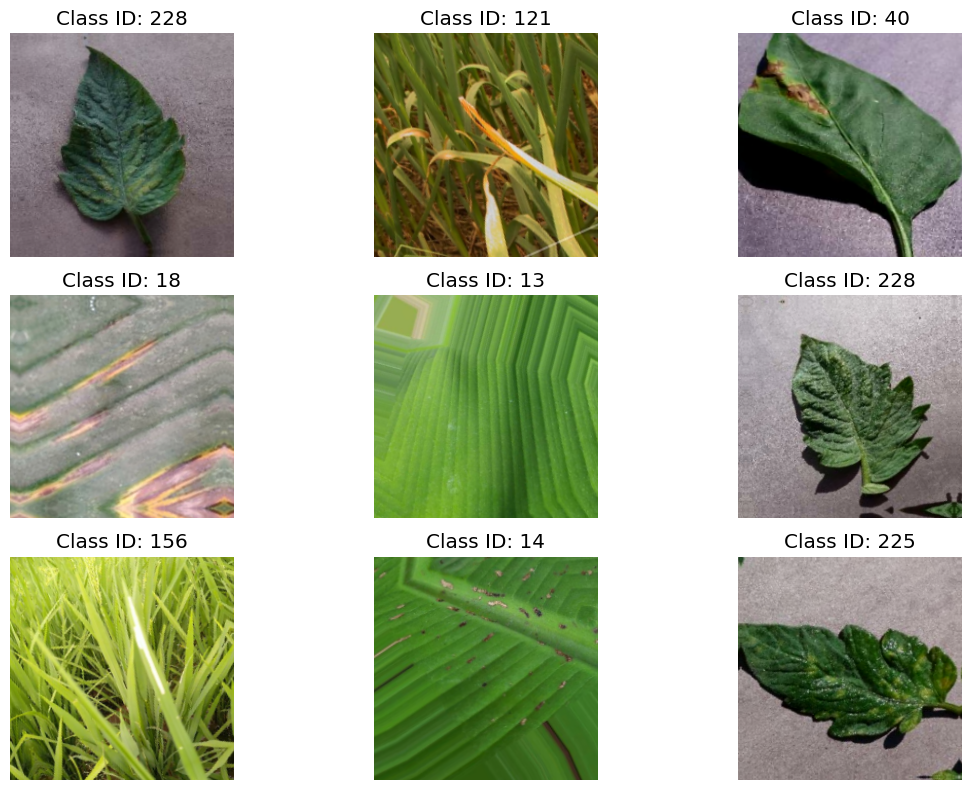

In [40]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    
    for i in range(9):
        
        plt.subplot(3, 3, i + 1)
        
        plt.imshow(
            tf.cast(images[i], tf.uint8)
        )
        
        plt.title(
            train_df.iloc[int(labels[i])]["canonical_class"]
            if False else f"Class ID: {labels[i].numpy()}"
        )
        
        plt.axis("off")

plt.tight_layout()
plt.show()

## 8.MODEL BUILDING

A transfer learning approach is used because training a deep CNN from scratch on 281 classes would require substantial computational resources.

EfficientNetB0 is used as the pretrained feature extractor.

The ImageNet-trained convolutional layers learn general visual features such as:

- Edges
- Shapes
- Textures
- Patterns

A custom classification head is then added to classify the 281 plant disease categories.

### 8.1 Create EfficientNetB0

In [47]:
#Load EfficientNetB0 pretrained on ImageNet

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

print("Base model loaded successfully.")
print("Input shape:", base_model.input_shape)
print("Output shape:", base_model.output_shape)

Base model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 7, 7, 1280)


### 8.2 Freeze Base Model

In [48]:
base_model.trainable = False
print("Trainable:", base_model.trainable)

Trainable: False


### 8.3 Determine Number of Classes

In [49]:
unique_class_ids = sorted(
    train_df["class_id"].unique()
)

print("Minimum class ID:", min(unique_class_ids))
print("Maximum class ID:", max(unique_class_ids))
print("Number of unique IDs:", len(unique_class_ids))

print(
    "Contiguous IDs:",
    unique_class_ids == list(range(len(unique_class_ids)))
)

Minimum class ID: 0
Maximum class ID: 280
Number of unique IDs: 281
Contiguous IDs: True


In [50]:
NUM_CLASSES = train_df["class_id"].nunique()

print("Number of classes:", NUM_CLASSES)

Number of classes: 281


### 8.4 Build Classification Model

In [51]:
inputs = tf.keras.Input(
    shape=IMG_SIZE + (3,),
    name="input_image"
)

# EfficientNet feature extractor
x = base_model(
    inputs,
    training=False
)

# Convert spatial feature maps into a feature vector
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Normalize extracted features
x = tf.keras.layers.BatchNormalization(
    name="batch_normalization"
)(x)

# Reduce overfitting
x = tf.keras.layers.Dropout(
    0.4,
    name="dropout"
)(x)

# Final 281-class prediction
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="PlantDisease_EfficientNetB0"
)

print("Model created successfully.")

Model created successfully.


### 8.5 Model Summary

In [52]:
model.summary()

Model: "PlantDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling               │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 281)                 │         359,961 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,414,652 (16.84 MB)

 Trainable params: 362,521 (1.38 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### 8.6 Compile the Model

In [53]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

## 9.TRAINING

### 9.1 Create Output Directory

In [54]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

### 9.2 Callbacks

In [55]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(
            MODEL_DIR,
            "plant_disease_best.keras"
        ),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

### 9.3 Initial Training

In [56]:
INITIAL_EPOCHS = 10

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.5160 - loss: 2.2577 - top_5_accuracy: 0.7534
Epoch 1: val_accuracy improved from None to 0.71109, saving model to models\plant_disease_best.keras

Epoch 1: finished saving model to models\plant_disease_best.keras
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 2892s 864ms/step - accuracy: 0.6038 - loss: 1.7545 - top_5_accuracy: 0.8268 - val_accuracy: 0.7111 - val_loss: 1.1750 - val_top_5_accuracy: 0.8993 - learning_rate: 0.0010
Epoch 2/10
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.6902 - loss: 1.2235 - top_5_accuracy: 0.8968
Epoch 2: val_accuracy improved from 0.71109 to 0.74138, saving model to models\plant_disease_best.keras

Epoch 2: finished saving model to models\plant_disease_best.keras
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 2846s 853ms/step - accuracy: 0.6924 - loss: 1.2020 - top_5_accuracy: 0.8994 - val_accuracy: 0.7414 - val_loss: 1.0888 - val_top_5_accuracy: 0.9114 - learning_rate: 0.0010
Epoch 3/10
3335/3335 ━━━━━━

### 9..4 Plot Training Curves

In [57]:
history_df = pd.DataFrame(history_initial.history)
history_df.head()

,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,0.603823,1.754507,0.826780,0.711094,1.175009,0.899250,0.001
1,0.692429,1.202026,0.899419,0.741379,1.088754,0.911394,0.001
2,0.720858,1.051915,0.918797,0.744678,1.042362,0.916492,0.001
3,0.732796,0.969284,0.929104,0.748726,1.028037,0.917991,0.001
4,0.739693,0.918701,0.935082,0.759670,0.994982,0.920690,0.001


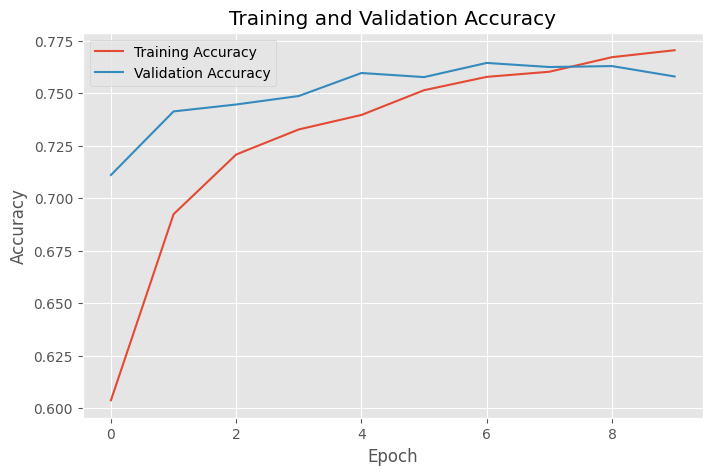

In [58]:
#ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(
    history_initial.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history_initial.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

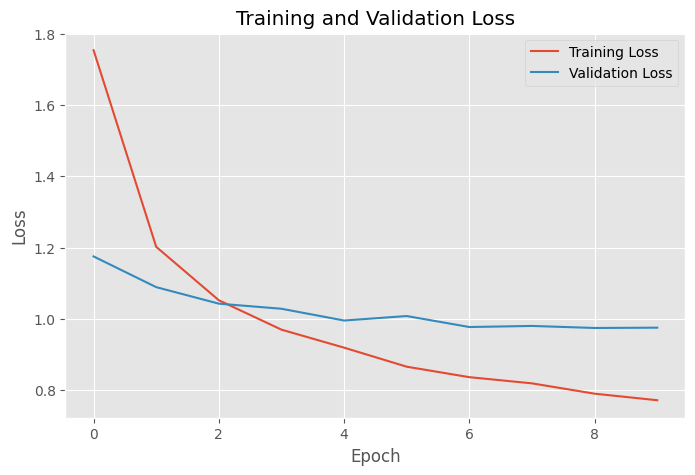

In [59]:
#LOSS
plt.figure(figsize=(8, 5))
plt.plot(
    history_initial.history["loss"],
    label="Training Loss"
)
plt.plot(
    history_initial.history["val_loss"],
    label="Validation Loss"
)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 9.5 Fine-Tuning

After training the classification head, selected layers of EfficientNetB0 are unfrozen.

The pretrained weights are then fine-tuned using a very small learning rate.

This allows the model to adapt ImageNet features to plant disease characteristics while reducing the risk of destroying useful pretrained features.

In [60]:
#Unfreeze the Last Layers
base_model.trainable = True

#Freeze most layers:
for layer in base_model.layers[:-30]:
    layer.trainable = False

#check
trainable_layers = sum(
    layer.trainable for layer in base_model.layers
)
print("Trainable Base Model Layers:", trainable_layers)

Trainable Base Model Layers: 30


### 9.6 Recompile With Small Learning Rate

In [61]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

### 9.7 Fine-Tuning Training

In [62]:
FINE_TUNE_EPOCHS = 10
total_epochs = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=len(history_initial.history["loss"]),
    callbacks=callbacks
)

Epoch 11/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.6364 - loss: 1.4097 - top_5_accuracy: 0.8703
Epoch 11: val_accuracy did not improve from 0.76447
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 3373s 1s/step - accuracy: 0.6732 - loss: 1.2221 - top_5_accuracy: 0.8960 - val_accuracy: 0.7565 - val_loss: 0.9807 - val_top_5_accuracy: 0.9181 - learning_rate: 1.0000e-05
Epoch 12/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.7197 - loss: 1.0118 - top_5_accuracy: 0.9213
Epoch 12: val_accuracy improved from 0.76447 to 0.77151, saving model to models\plant_disease_best.keras

Epoch 12: finished saving model to models\plant_disease_best.keras
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 3560s 1s/step - accuracy: 0.7329 - loss: 0.9448 - top_5_accuracy: 0.9302 - val_accuracy: 0.7715 - val_loss: 0.9190 - val_top_5_accuracy: 0.9240 - learning_rate: 1.0000e-05
Epoch 13/20
3335/3335 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.7474 - loss: 0.8911 - top_5_accuracy: 0.9355
Epoch 13: val_accurac

### 9.8 Save Final Model 

In [63]:
FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "plant_disease_efficientnetb0.keras"
)

model.save(FINAL_MODEL_PATH)
print("Model saved to:", FINAL_MODEL_PATH)

Model saved to: models\plant_disease_efficientnetb0.keras


## 10.EVALUATION

### 10.1 Load Best Model

In [64]:
best_model = tf.keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "plant_disease_best.keras"
    )
)

### 10.2 Test Evaluation

In [65]:
test_results = best_model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

print("\nTest Results")
print("-" * 40)

for metric_name, value in test_results.items():
    print(f"{metric_name}: {value:.4f}")

417/417 ━━━━━━━━━━━━━━━━━━━━ 296s 699ms/step - accuracy: 0.8149 - loss: 0.7381 - top_5_accuracy: 0.9420

Test Results
----------------------------------------
accuracy: 0.8149
loss: 0.7381
top_5_accuracy: 0.9420


### 10.3 Generate Predictions

In [67]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    predictions = best_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

    y_prob.extend(
        predictions
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

y_true shape: (6671,)
y_pred shape: (6671,)
y_prob shape: (6671, 281)


### 10.4 Classification Report

In [68]:
from sklearn.metrics import classification_report

class_mapping = (
    train_df[
        ["class_id", "canonical_class"]
    ]
    .drop_duplicates()
    .sort_values("class_id")
)
class_names = class_mapping["canonical_class"].tolist()

print("Number of class names:", len(class_names))
print("Number of classes:", NUM_CLASSES)

Number of class names: 281
Number of classes: 281


### 10.5 Classification Report

In [69]:
report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    zero_division=0
)

print(report)

                                                                  precision    recall  f1-score   support

                                                 Apple - Healthy       0.42      0.56      0.48         9
                                                    Apple - Rust       0.40      0.44      0.42         9
                                                    Apple - Scab       0.22      0.22      0.22         9
                                         Apple - apple black rot       1.00      0.20      0.33         5
                                        Apple - apple black rot        1.00      0.50      0.67         2
                                      Apple - apple mosaic virus       0.40      0.50      0.44         4
                                     Apple - apple mosaic virus        1.00      0.75      0.86         4
                                              Apple - apple rust       0.00      0.00      0.00         6
                                             

### 10..6 Overall Metrics

In [70]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8149


### 10.7 Macro / Weighted F1

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")

Macro Precision : 0.4465
Macro Recall    : 0.4274
Macro F1       : 0.4228


### 10.8 Confusion Matrix

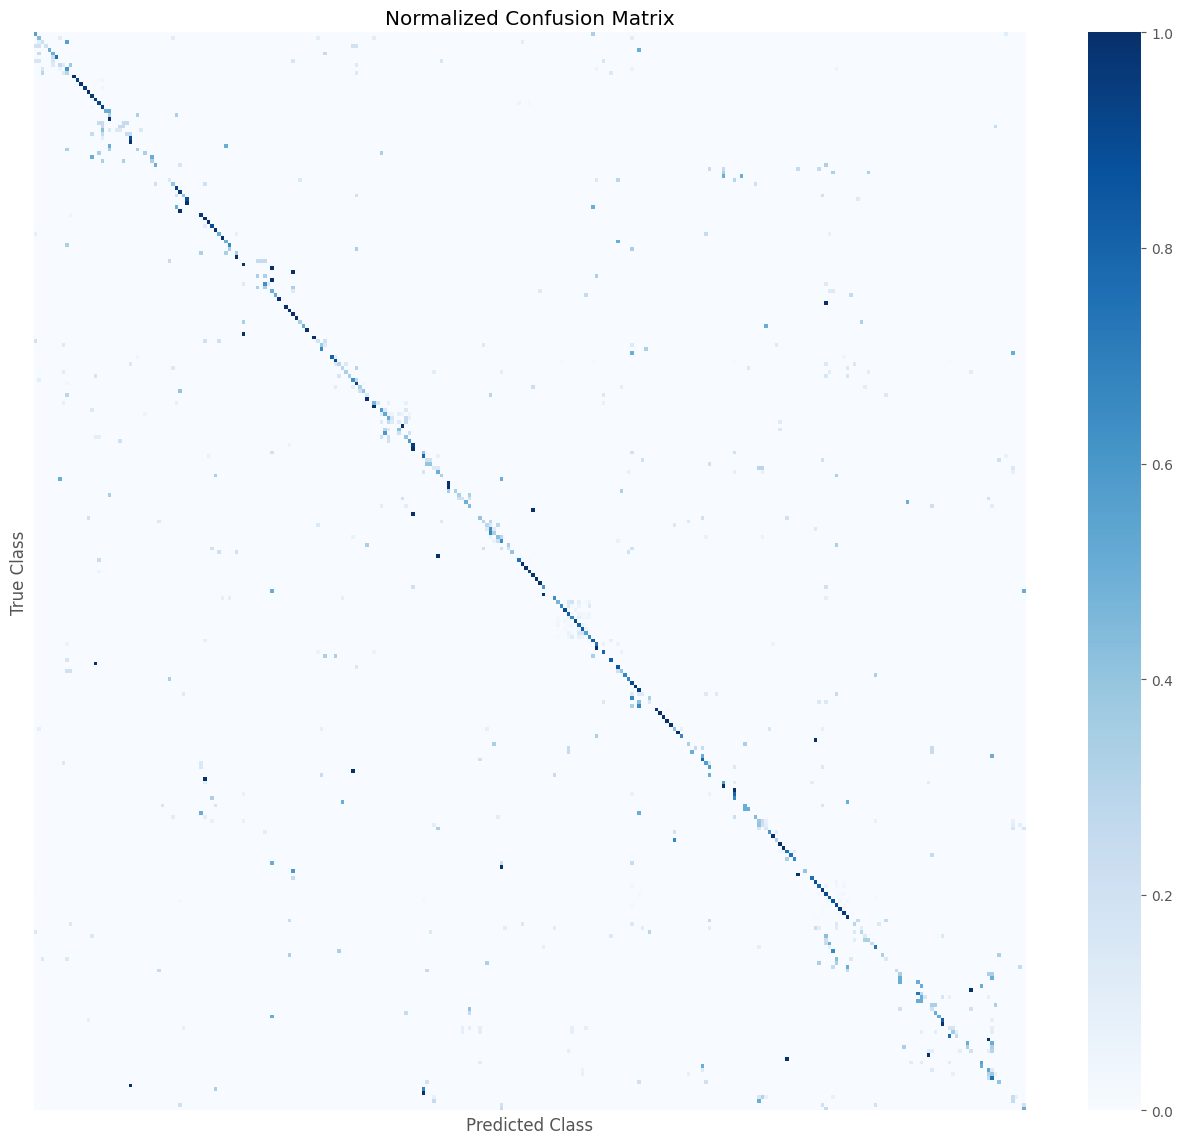

In [72]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    normalize="true"
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### 10.9 Top-5 Accuracy

In [73]:
top5_predictions = np.argsort(
    y_prob,
    axis=1
)[:, -5:]

top5_correct = np.array([
    true_label in predictions
    for true_label, predictions
    in zip(y_true, top5_predictions)
])

top5_accuracy = top5_correct.mean()

print(f"Top-5 Accuracy: {top5_accuracy:.4f}")

Top-5 Accuracy: 0.9420


### 10.10 Confidence Analysis

In [74]:
confidence = np.max(
    y_prob,
    axis=1
)
print("Average Confidence:",
      confidence.mean())
print("Minimum Confidence:",
      confidence.min())
print("Maximum Confidence:",
      confidence.max())

Average Confidence: 0.86171573
Minimum Confidence: 0.090535045
Maximum Confidence: 1.0


### 10.11 Confidence Distribution

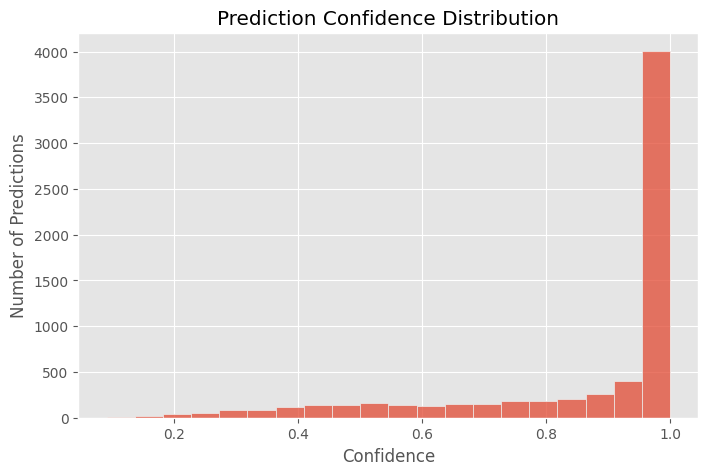

In [75]:
plt.figure(figsize=(8, 5))
sns.histplot(
    confidence,
    bins=20
)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Predictions")
plt.show()

### 10.12 Correct vs Incorrect Confidence

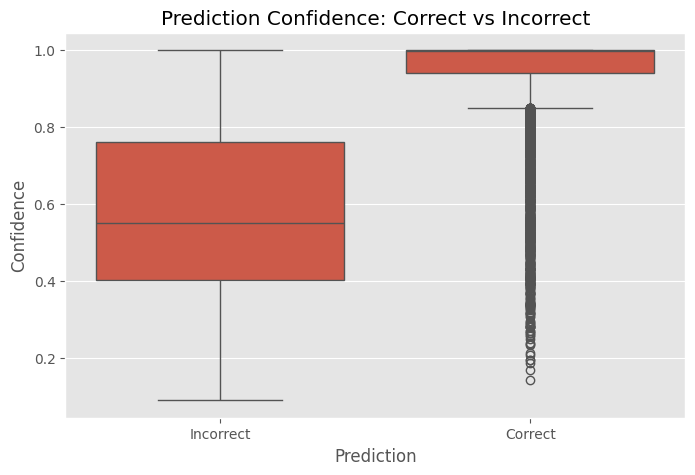

In [76]:
correct = y_true == y_pred

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=correct,
    y=confidence
)

plt.xticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

plt.title("Prediction Confidence: Correct vs Incorrect")

plt.xlabel("Prediction")

plt.ylabel("Confidence")

plt.show()

### 10.13 Show Correct Predictions

In [77]:
def display_predictions(
    dataset,
    model,
    class_names,
    num_images=9
):
    
    for images, labels in dataset.take(1):
        
        predictions = model.predict(
            images,
            verbose=0
        )
        
        predicted_classes = np.argmax(
            predictions,
            axis=1
        )
        
        confidence = np.max(
            predictions,
            axis=1
        )
        
        plt.figure(figsize=(12, 12))
        
        for i in range(
            min(num_images, len(images))
        ):
            
            plt.subplot(3, 3, i + 1)
            
            plt.imshow(
                images[i].numpy().astype("uint8")
            )
            
            true_name = class_names[
                labels[i].numpy()
            ]
            
            pred_name = class_names[
                predicted_classes[i]
            ]
            
            plt.title(
                f"True: {true_name[:25]}\n"
                f"Pred: {pred_name[:25]}\n"
                f"Confidence: {confidence[i]:.2%}",
                fontsize=8
            )
            
            plt.axis("off")
        
        plt.tight_layout()
        plt.show()

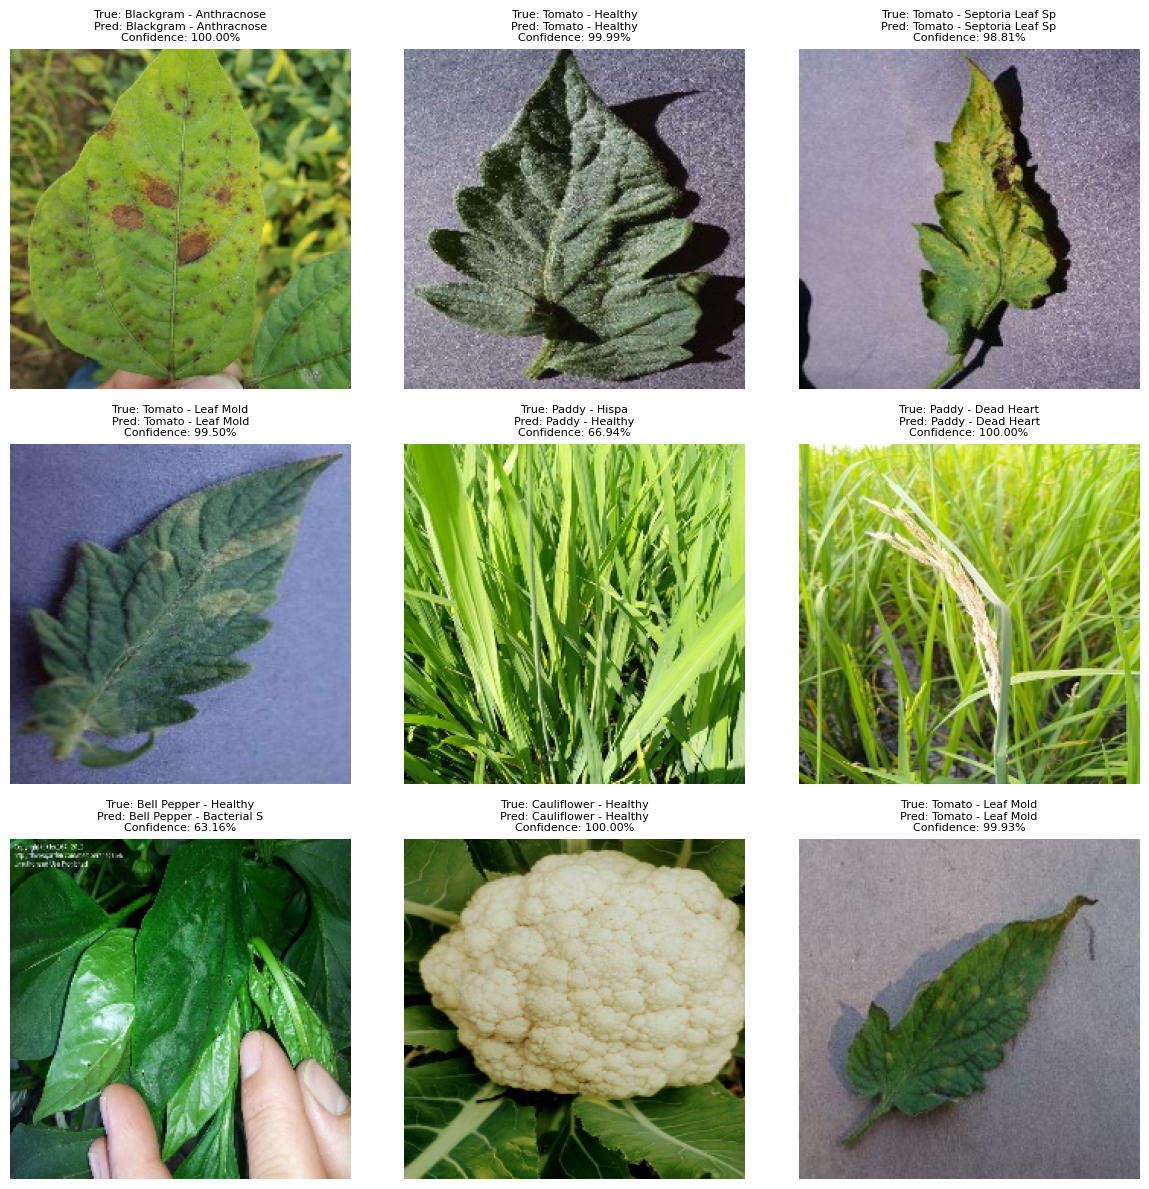

In [78]:
display_predictions(
    test_ds,
    best_model,
    class_names
)

## 11.EXPLAINABLE AI

Deep learning models can achieve high classification performance while behaving as black boxes.

Grad-CAM is used to visualize the regions of an image that contributed most strongly to the model's prediction.

For plant disease classification, this helps determine whether the model is focusing on relevant leaf regions rather than irrelevant background areas.

###  11.1 Find EfficientNet Layer

In [79]:
for layer in best_model.layers:
    print(layer.name)

#For Finding the last convolutional layer:
base_model_loaded = best_model.get_layer(
    "efficientnetb0"
)
for layer in base_model_loaded.layers[-20:]:
    print(layer.name, layer.output.shape)

input_image
efficientnetb0
global_average_pooling
batch_normalization
dropout
predictions
block6d_project_conv (None, 7, 7, 192)
block6d_project_bn (None, 7, 7, 192)
block6d_drop (None, 7, 7, 192)
block6d_add (None, 7, 7, 192)
block7a_expand_conv (None, 7, 7, 1152)
block7a_expand_bn (None, 7, 7, 1152)
block7a_expand_activation (None, 7, 7, 1152)
block7a_dwconv (None, 7, 7, 1152)
block7a_bn (None, 7, 7, 1152)
block7a_activation (None, 7, 7, 1152)
block7a_se_squeeze (None, 1152)
block7a_se_reshape (None, 1, 1, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_expand (None, 1, 1, 1152)
block7a_se_excite (None, 7, 7, 1152)
block7a_project_conv (None, 7, 7, 320)
block7a_project_bn (None, 7, 7, 320)
top_conv (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_activation (None, 7, 7, 1280)


### 11.2 Grad-CAM Function

In [80]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(
                "efficientnetb0"
            ).get_layer(
                last_conv_layer_name
            ).output,
            model.output
        ]
    )
    
    with tf.GradientTape() as tape:
        
        conv_outputs, predictions = grad_model(
            img_array
        )
        
        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )
        
        class_channel = predictions[
            :, pred_index
        ]
    
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )
    
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )
    
    conv_outputs = conv_outputs[0]
    
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(
        heatmap,
        0
    )
    
    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )
    
    return heatmap.numpy()

### 11.3 Identify the Layer

In [81]:
for layer in base_model_loaded.layers:
    if len(layer.output.shape) == 4:
        print(layer.name)

input_layer_5
rescaling_8
normalization_4
rescaling_9
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_reshape
block3a_se_reduce
block3a_se_expand
block3a_se_excite
block3a_project_conv
block3a_project_bn
block3b_exp

In [82]:
LAST_CONV_LAYER = "top_activation"
print("Grad-CAM layer:", LAST_CONV_LAYER)
print("Output shape:", base_model_loaded.get_layer(LAST_CONV_LAYER).output.shape)

Grad-CAM layer: top_activation
Output shape: (None, 7, 7, 1280)


### 11.4 Generate Heatmap

In [87]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):
    
    # --------------------------------------------------
    # 1. Get EfficientNetB0 base model
    # --------------------------------------------------
    base_model = model.get_layer("efficientnetb0")
    
    # --------------------------------------------------
    # 2. Get target Grad-CAM layer
    # --------------------------------------------------
    target_layer = base_model.get_layer(
        last_conv_layer_name
    )
    
    # --------------------------------------------------
    # 3. Create feature model
    #    Outputs:
    #    - target convolutional feature maps
    #    - EfficientNet feature output
    # --------------------------------------------------
    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            target_layer.output,
            base_model.output
        ]
    )
    
    # --------------------------------------------------
    # 4. Get classification head
    # --------------------------------------------------
    gap = model.get_layer(
        "global_average_pooling"
    )
    
    bn = model.get_layer(
        "batch_normalization"
    )
    
    dropout = model.get_layer(
        "dropout"
    )
    
    classifier = model.get_layer(
        "predictions"
    )
    
    # --------------------------------------------------
    # 5. Forward pass + gradient calculation
    # --------------------------------------------------
    with tf.GradientTape() as tape:
        
        conv_outputs, base_features = feature_model(
            img_array
        )
        
        # Classification head
        x = gap(base_features)
        
        x = bn(
            x,
            training=False
        )
        
        x = dropout(
            x,
            training=False
        )
        
        predictions = classifier(x)
        
        # If class isn't provided,
        # use the predicted class
        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )
        
        class_channel = predictions[
            :,
            pred_index
        ]
    
    # --------------------------------------------------
    # 6. Calculate gradients
    # --------------------------------------------------
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )
    
    # --------------------------------------------------
    # 7. Global average pooling of gradients
    # --------------------------------------------------
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )
    
    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    
    # --------------------------------------------------
    # 8. Weight feature maps by gradients
    # --------------------------------------------------
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )
    
    # --------------------------------------------------
    # 9. ReLU
    # --------------------------------------------------
    heatmap = tf.maximum(
        heatmap,
        0
    )
    
    # --------------------------------------------------
    # 10. Normalize heatmap
    # --------------------------------------------------
    max_value = tf.reduce_max(
        heatmap
    )
    
    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )
    
    return heatmap.numpy()

In [88]:
LAST_CONV_LAYER = "top_activation"

print(
    "Grad-CAM layer:",
    LAST_CONV_LAYER
)

print(
    "Layer output shape:",
    best_model
    .get_layer("efficientnetb0")
    .get_layer(LAST_CONV_LAYER)
    .output.shape
)

Grad-CAM layer: top_activation
Layer output shape: (None, 7, 7, 1280)


In [89]:
for images, labels in test_ds.take(1):
    
    # --------------------------------------------------
    # Get one test image
    # --------------------------------------------------
    sample_image = images[0]
    
    img_array = tf.expand_dims(
        sample_image,
        axis=0
    )
    
    # --------------------------------------------------
    # Model prediction
    # --------------------------------------------------
    prediction = best_model.predict(
        img_array,
        verbose=0
    )
    
    predicted_class = int(
        np.argmax(
            prediction[0]
        )
    )
    
    predicted_confidence = float(
        np.max(
            prediction[0]
        )
    )
    
    # --------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------
    heatmap = make_gradcam_heatmap(
        img_array,
        best_model,
        LAST_CONV_LAYER,
        predicted_class
    )
    
    # --------------------------------------------------
    # True label
    # --------------------------------------------------
    true_class = int(
        labels[0].numpy()
    )
    
    break


print(
    "True class:",
    class_names[true_class]
)

print(
    "Predicted class:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    f"{predicted_confidence:.2%}"
)

print(
    "Heatmap shape:",
    heatmap.shape
)

True class: Blackgram - Anthracnose
Predicted class: Blackgram - Anthracnose
Confidence: 100.00%
Heatmap shape: (7, 7)


### 11.5 Display Grad-CAM

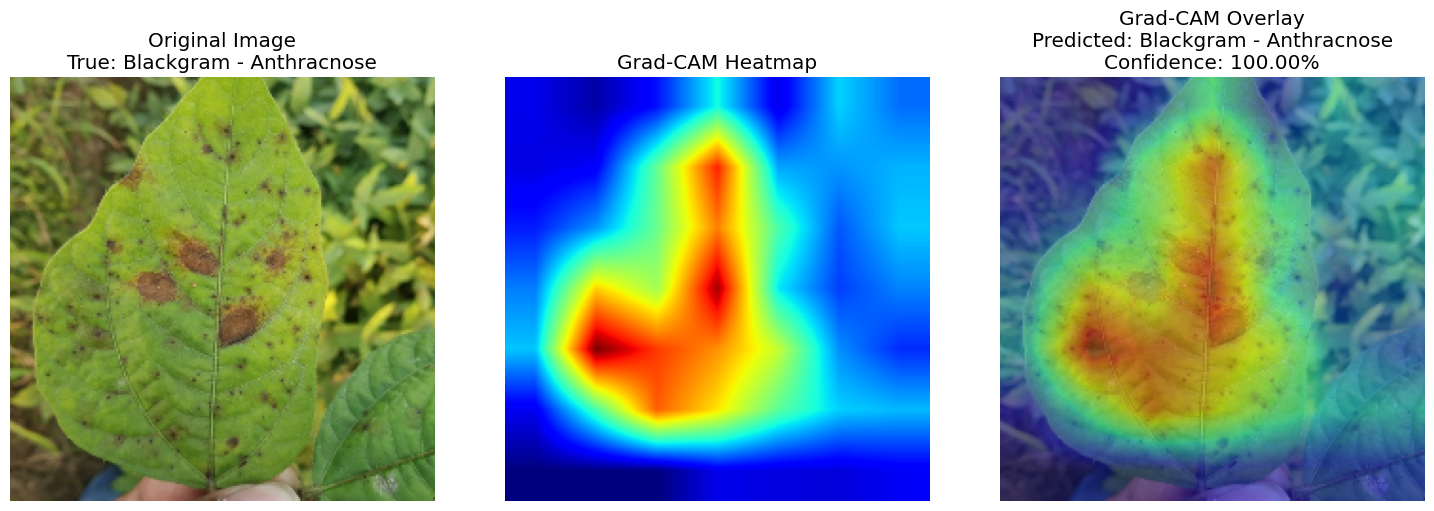

In [91]:
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (IMG_SIZE[0], IMG_SIZE[1])
).numpy().squeeze()


plt.figure(figsize=(15, 5))


# --------------------------------------------------
# Original image
# --------------------------------------------------
plt.subplot(1, 3, 1)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.title(
    f"Original Image\n"
    f"True: {class_names[true_class]}"
)

plt.axis("off")


# --------------------------------------------------
# Grad-CAM heatmap
# --------------------------------------------------
plt.subplot(1, 3, 2)

plt.imshow(
    heatmap_resized,
    cmap="jet"
)

plt.title(
    "Grad-CAM Heatmap"
)

plt.axis("off")


# --------------------------------------------------
# Grad-CAM overlay
# --------------------------------------------------
plt.subplot(1, 3, 3)

plt.imshow(
    sample_image.numpy().astype("uint8")
)

plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)

plt.title(
    f"Grad-CAM Overlay\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {predicted_confidence:.2%}"
)

plt.axis("off")


plt.tight_layout()
plt.show()

## 12.SAVING EVERYTHING REQUIRED FOR STREAMLIT

### 12.1 Save Class Mapping

In [92]:
class_mapping = (
    train_df[
        ["class_id", "canonical_class"]
    ]
    .drop_duplicates()
    .sort_values("class_id")
)

class_mapping_dict = {
    str(int(row["class_id"])): row["canonical_class"]
    for _, row in class_mapping.iterrows()
}

with open(
    os.path.join(MODEL_DIR, "class_names.json"),
    "w"
) as f:
    
    json.dump(
        class_mapping_dict,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    f"Saved {len(class_mapping_dict)} class mappings."
)

Saved 281 class mappings.


### 12.2 Save Configuration

In [93]:
config = {
    "image_size": [224, 224],
    "num_classes": int(NUM_CLASSES),
    "model": "EfficientNetB0",
    "weights": "ImageNet",
    "dropout": 0.4,
    "input_channels": 3,
    "gradcam_layer": LAST_CONV_LAYER
}

with open(
    os.path.join(MODEL_DIR, "config.json"),
    "w"
) as f:
    
    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved.")

Configuration saved.


### 12.3 Save a model metadata file

In [94]:
model_metadata = {
    "architecture": "EfficientNetB0",
    "transfer_learning": True,
    "pretrained_weights": "ImageNet",
    "num_classes": int(NUM_CLASSES),
    "image_size": [224, 224],
    "batch_size": BATCH_SIZE,
    "initial_learning_rate": 1e-3,
    "fine_tuning_learning_rate": 1e-5,
    "fine_tuned_layers": 30,
    "dropout": 0.4,
    "test_accuracy": float(accuracy),
    "top_5_accuracy": float(top5_accuracy),
    "macro_precision": float(precision),
    "macro_recall": float(recall),
    "macro_f1": float(f1)
}

with open(
    os.path.join(MODEL_DIR, "model_metadata.json"),
    "w"
) as f:
    
    json.dump(
        model_metadata,
        f,
        indent=4
    )

print("Model metadata saved.")

Model metadata saved.


### 1. Project Setup
### 2. Dataset Loading
### 3. Dataset Inspection
### 4. Data Quality Checks
### 5. Exploratory Data Analysis
### 6. Data Preprocessing
### 7. Model Building
### 8. Model Training
### 9. Model Fine-Tuning
### 10. Model Evaluation
### 11. Explainable AI - Grad-CAM
### 12. Model Export & Streamlit Preparation

In [203]:
print(tf.config.list_physical_devices("GPU"))

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("CPU devices:", tf.config.list_physical_devices("CPU"))

[]
TensorFlow version: 2.21.0
GPU devices: []
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
